# Welcome to Colab!

In [1]:
pip install pandas matplotlib seaborn

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


# ── Load Data
df = pd.read_csv('/content/WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Convert Attrition to binary number
df['Attrition_Num'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# ── 1. Basic Overview
print("=" * 55)
print("  HR ATTRITION - EXPLORATORY DATA ANALYSIS")
print("=" * 55)
print(f"\nTotal Employees  : {len(df)}")
print(f"Total Columns    : {df.shape[1]}")
print(f"Null Values      : {df.isnull().sum().sum()}")
print(f"Duplicate Rows   : {df.duplicated().sum()}")
print("\nColumn Names:")
print(list(df.columns))








  HR ATTRITION - EXPLORATORY DATA ANALYSIS

Total Employees  : 1470
Total Columns    : 36
Null Values      : 0
Duplicate Rows   : 0

Column Names:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Attrition_Num']


In [10]:
# ── 2. Attrition Rate ──────────────────────────────────────────────────────
total     = len(df)
left      = df['Attrition'].value_counts()['Yes']
stayed    = df['Attrition'].value_counts()['No']
attr_rate = round((left / total) * 100, 2)

print("\n[ATTRITION SUMMARY]")
print(f"  Total Employees  : {total}")
print(f"  Employees Left   : {left}")
print(f"  Employees Stayed : {stayed}")
print(f"  Attrition Rate   : {attr_rate}%")


[ATTRITION SUMMARY]
  Total Employees  : 1470
  Employees Left   : 237
  Employees Stayed : 1233
  Attrition Rate   : 16.12%


In [11]:
# ── 3. Attrition by Department ─────────────────────────────────────────────
print("\n[ATTRITION BY DEPARTMENT]")
dept = df.groupby('Department')['Attrition_Num'].agg(['sum','count'])
dept.columns = ['Left', 'Total']
dept['Rate%'] = (dept['Left'] / dept['Total'] * 100).round(2)
print(dept)


[ATTRITION BY DEPARTMENT]
                        Left  Total  Rate%
Department                                
Human Resources           12     63  19.05
Research & Development   133    961  13.84
Sales                     92    446  20.63


In [12]:


# ── 4. Attrition by Job Role ───────────────────────────────────────────────
print("\n[ATTRITION BY JOB ROLE]")
role = df.groupby('JobRole')['Attrition_Num'].agg(['sum','count'])
role.columns = ['Left', 'Total']
role['Rate%'] = (role['Left'] / role['Total'] * 100).round(2)
role = role.sort_values('Rate%', ascending=False)
print(role)


[ATTRITION BY JOB ROLE]
                           Left  Total  Rate%
JobRole                                      
Sales Representative         33     83  39.76
Laboratory Technician        62    259  23.94
Human Resources              12     52  23.08
Sales Executive              57    326  17.48
Research Scientist           47    292  16.10
Manufacturing Director       10    145   6.90
Healthcare Representative     9    131   6.87
Manager                       5    102   4.90
Research Director             2     80   2.50


In [13]:

# ── 5. Attrition by Gender ─────────────────────────────────────────────────
print("\n[ATTRITION BY GENDER]")
gender = df.groupby('Gender')['Attrition_Num'].agg(['sum','count'])
gender.columns = ['Left', 'Total']
gender['Rate%'] = (gender['Left'] / gender['Total'] * 100).round(2)
print(gender)


[ATTRITION BY GENDER]
        Left  Total  Rate%
Gender                    
Female    87    588  14.80
Male     150    882  17.01


In [15]:
# ── 6. OverTime vs Attrition ───────────────────────────────────────────────
print("\n[OVERTIME vs ATTRITION]")
ot = df.groupby('OverTime')['Attrition_Num'].agg(['sum','count'])
ot.columns = ['Left', 'Total']
ot['Rate%'] = (ot['Left'] / ot['Total'] * 100).round(2)
print(ot)









[OVERTIME vs ATTRITION]
          Left  Total  Rate%
OverTime                    
No         110   1054  10.44
Yes        127    416  30.53


In [16]:
# ── 7. Age Group Analysis ──────────────────────────────────────────────────
print("\n[ATTRITION BY AGE GROUP]")
df['AgeGroup'] = pd.cut(df['Age'],
                         bins=[18, 25, 35, 45, 60],
                         labels=['18-25', '26-35', '36-45', '46-60'])
age_grp = df.groupby('AgeGroup', observed=True)['Attrition_Num'].agg(['sum','count'])
age_grp.columns = ['Left', 'Total']
age_grp['Rate%'] = (age_grp['Left'] / age_grp['Total'] * 100).round(2)
print(age_grp)


[ATTRITION BY AGE GROUP]
          Left  Total  Rate%
AgeGroup                    
18-25       40    115  34.78
26-35      116    606  19.14
36-45       43    468   9.19
46-60       34    273  12.45


In [17]:
# ── 8. Income Stats ────────────────────────────────────────────────────────
print("\n[MONTHLY INCOME - Left vs Stayed]")
inc = df.groupby('Attrition')['MonthlyIncome'].agg(['mean','median','min','max']).round(0)
print(inc)


[MONTHLY INCOME - Left vs Stayed]
             mean  median   min    max
Attrition                             
No         6833.0  5204.0  1051  19999
Yes        4787.0  3202.0  1009  19859


In [18]:

# ── 9. Job Satisfaction ────────────────────────────────────────────────────
print("\n[JOB SATISFACTION vs ATTRITION] (1=Low, 4=High)")
js = df.groupby('JobSatisfaction')['Attrition_Num'].agg(['sum','count'])
js.columns = ['Left', 'Total']
js['Rate%'] = (js['Left'] / js['Total'] * 100).round(2)
print(js)


[JOB SATISFACTION vs ATTRITION] (1=Low, 4=High)
                 Left  Total  Rate%
JobSatisfaction                    
1                  66    289  22.84
2                  46    280  16.43
3                  73    442  16.52
4                  52    459  11.33


In [19]:
# ── 10. Work-Life Balance ──────────────────────────────────────────────────
print("\n[WORK-LIFE BALANCE vs ATTRITION] (1=Bad, 4=Best)")
wlb = df.groupby('WorkLifeBalance')['Attrition_Num'].agg(['sum','count'])
wlb.columns = ['Left', 'Total']
wlb['Rate%'] = (wlb['Left'] / wlb['Total'] * 100).round(2)
print(wlb)


[WORK-LIFE BALANCE vs ATTRITION] (1=Bad, 4=Best)
                 Left  Total  Rate%
WorkLifeBalance                    
1                  25     80  31.25
2                  58    344  16.86
3                 127    893  14.22
4                  27    153  17.65


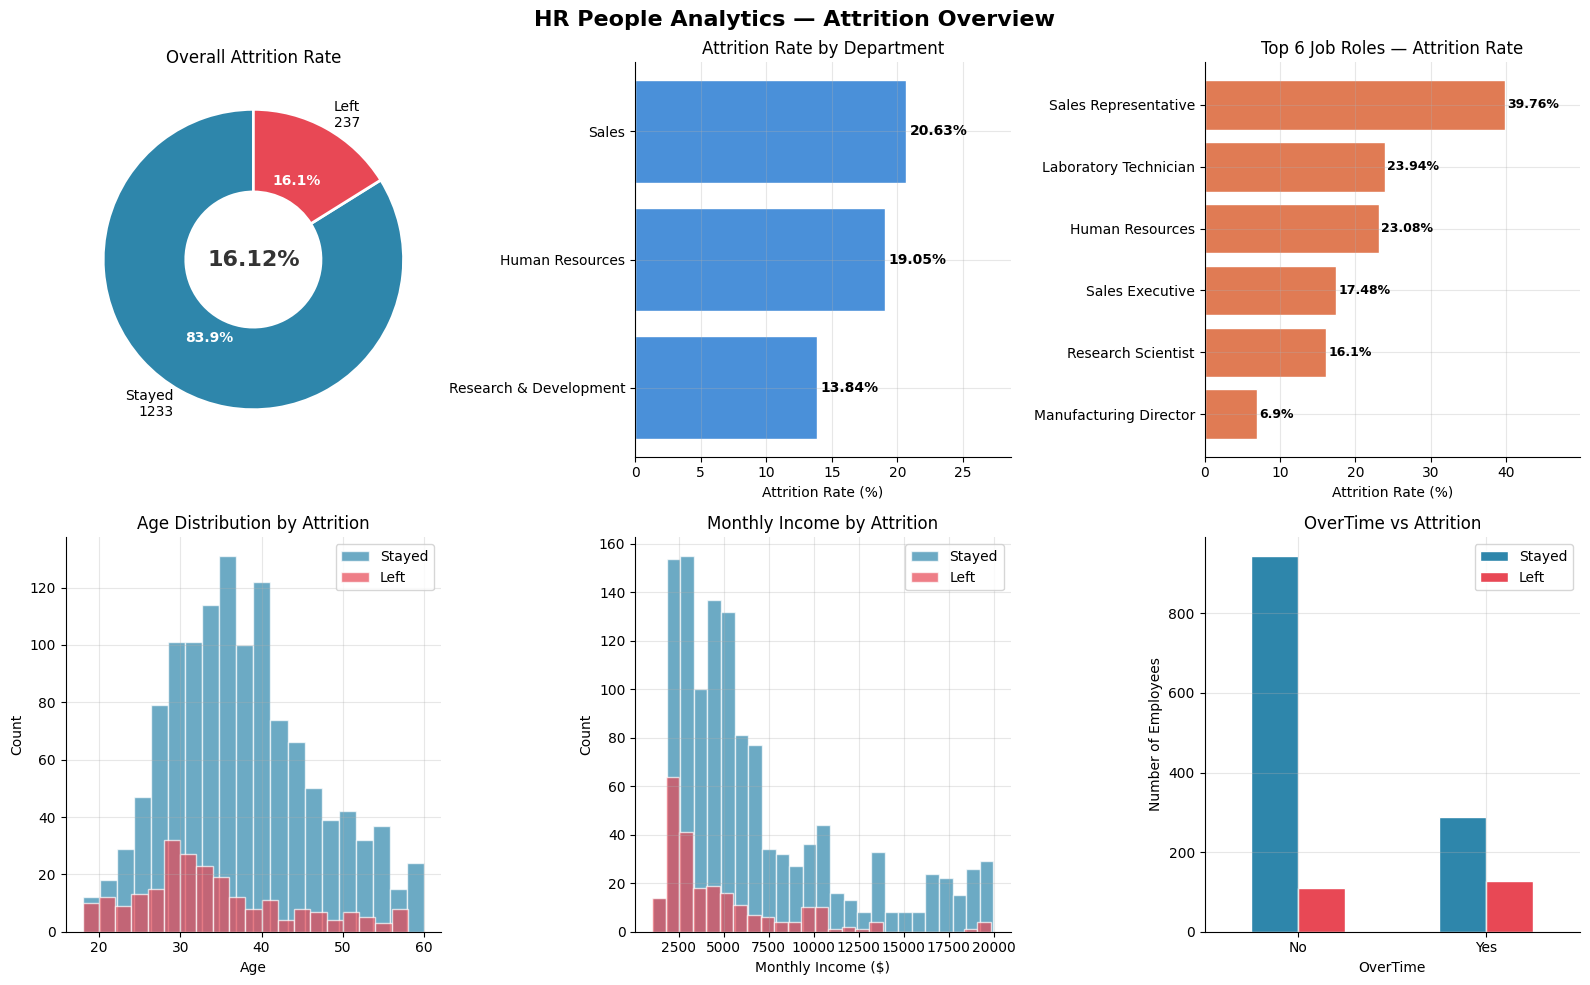

Chart 1 saved!


In [21]:

# ══════════════════════════════════════════════════════
#  CHART 1 — OVERVIEW (6 charts)
# ══════════════════════════════════════════════════════

colors_main = ['#2E86AB', '#E84855']
color_yes   = '#E84855'
color_no    = '#2E86AB'
color_bar   = '#4A90D9'

plt.rcParams.update({
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'figure.facecolor' : 'white',
})

fig1, axes = plt.subplots(2, 3, figsize=(16, 10))
fig1.suptitle('HR People Analytics — Attrition Overview',
              fontsize=16, fontweight='bold')

# Chart 1a — Attrition Donut
ax = axes[0, 0]
sizes  = [stayed, left]
labels = [f'Stayed\n{stayed}', f'Left\n{left}']
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, autopct='%1.1f%%',
    colors=colors_main, startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontweight('bold')
    at.set_color('white')
ax.set_title('Overall Attrition Rate')
ax.text(0, 0, f'{attr_rate}%', ha='center', va='center',
        fontsize=16, fontweight='bold', color='#333')

# Chart 1b — Attrition by Department
ax = axes[0, 1]
dept_plot = dept.sort_values('Rate%')
bars = ax.barh(dept_plot.index, dept_plot['Rate%'],
               color=color_bar, edgecolor='white')
for bar, val in zip(bars, dept_plot['Rate%']):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=10, fontweight='bold')
ax.set_title('Attrition Rate by Department')
ax.set_xlabel('Attrition Rate (%)')
ax.set_xlim(0, dept_plot['Rate%'].max() + 8)

# Chart 1c — Attrition by Job Role
ax = axes[0, 2]
role_plot = role.head(6).sort_values('Rate%')
bars = ax.barh(role_plot.index, role_plot['Rate%'],
               color='#E07B54', edgecolor='white')
for bar, val in zip(bars, role_plot['Rate%']):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=9, fontweight='bold')
ax.set_title('Top 6 Job Roles — Attrition Rate')
ax.set_xlabel('Attrition Rate (%)')
ax.set_xlim(0, role_plot['Rate%'].max() + 10)

# Chart 1d — Age Distribution
ax = axes[1, 0]
df[df['Attrition'] == 'No']['Age'].hist(
    ax=ax, bins=20, color=color_no, alpha=0.7, label='Stayed', edgecolor='white')
df[df['Attrition'] == 'Yes']['Age'].hist(
    ax=ax, bins=20, color=color_yes, alpha=0.7, label='Left', edgecolor='white')
ax.set_title('Age Distribution by Attrition')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend()

# Chart 1e — Monthly Income
ax = axes[1, 1]
df[df['Attrition'] == 'No']['MonthlyIncome'].hist(
    ax=ax, bins=25, color=color_no, alpha=0.7, label='Stayed', edgecolor='white')
df[df['Attrition'] == 'Yes']['MonthlyIncome'].hist(
    ax=ax, bins=25, color=color_yes, alpha=0.7, label='Left', edgecolor='white')
ax.set_title('Monthly Income by Attrition')
ax.set_xlabel('Monthly Income ($)')
ax.set_ylabel('Count')
ax.legend()

# Chart 1f — OverTime
ax = axes[1, 2]
ot_pivot = df.groupby(['OverTime', 'Attrition']).size().unstack()
ot_pivot.plot(kind='bar', ax=ax, color=colors_main,
              edgecolor='white', rot=0)
ax.set_title('OverTime vs Attrition')
ax.set_xlabel('OverTime')
ax.set_ylabel('Number of Employees')
ax.legend(['Stayed', 'Left'])

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved!")




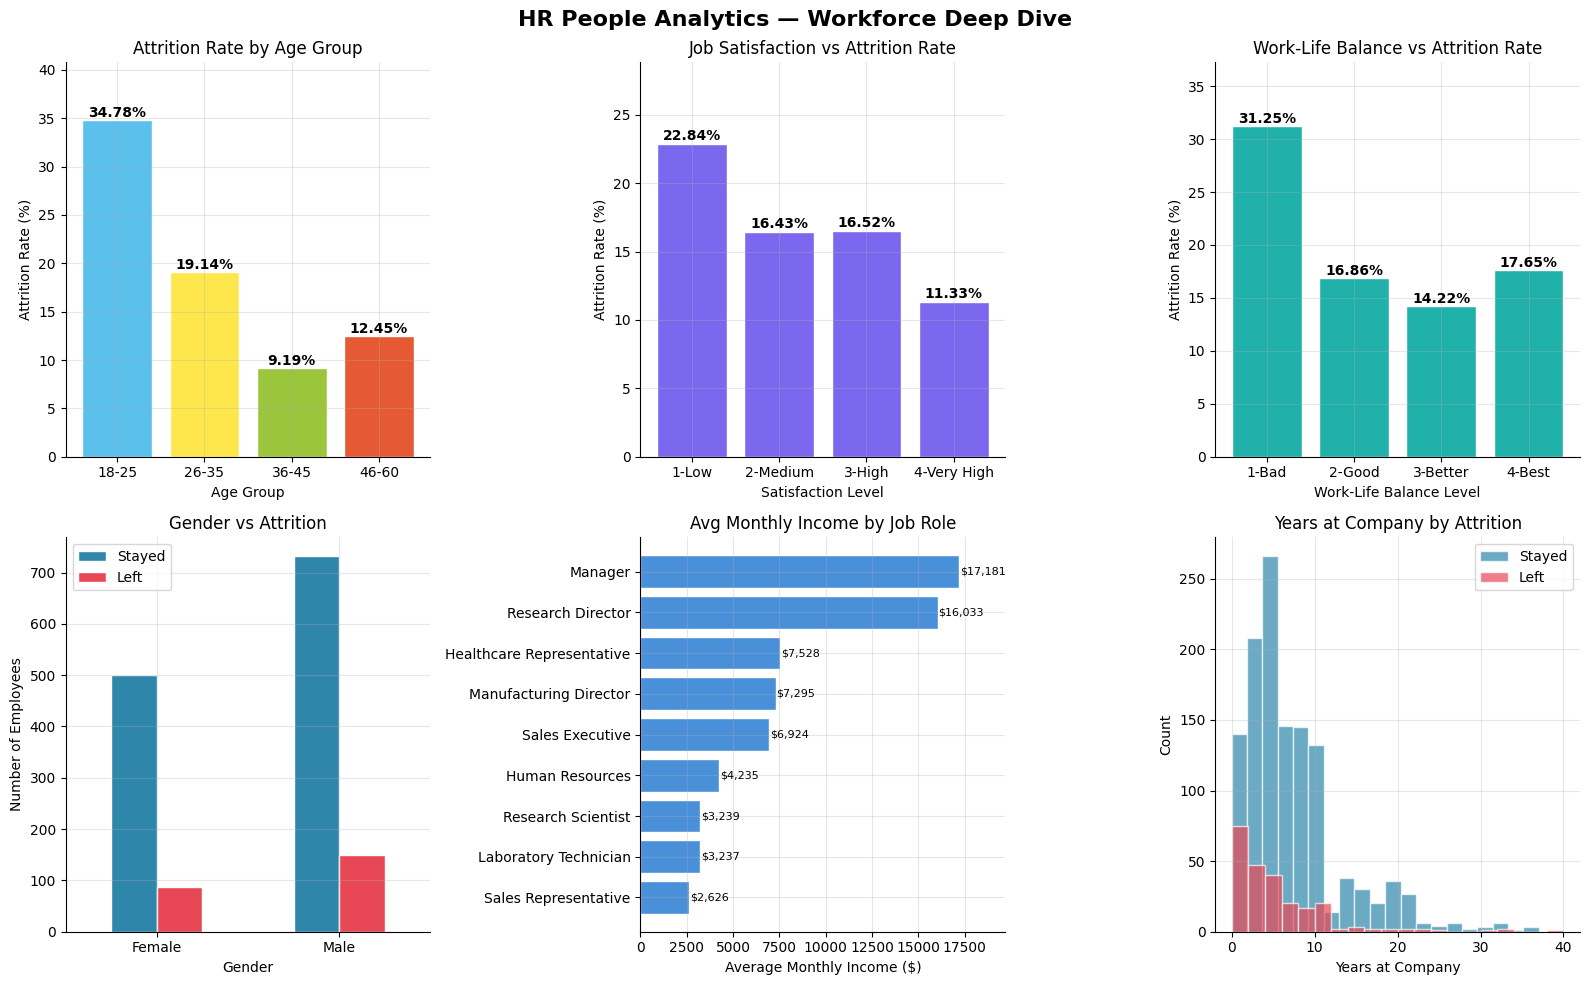

Chart 2 saved!


In [22]:
# ══════════════════════════════════════════════════════
#  CHART 2 — DEEP DIVE (6 charts)
# ══════════════════════════════════════════════════════

fig2, axes = plt.subplots(2, 3, figsize=(16, 10))
fig2.suptitle('HR People Analytics — Workforce Deep Dive',
              fontsize=16, fontweight='bold')

# Chart 2a — Age Group Attrition Rate
ax = axes[0, 0]
bars = ax.bar(age_grp.index.astype(str), age_grp['Rate%'],
              color=['#5BC0EB','#FDE74C','#9BC53D','#E55934'],
              edgecolor='white')
for bar, val in zip(bars, age_grp['Rate%']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val}%', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Attrition Rate by Age Group')
ax.set_xlabel('Age Group')
ax.set_ylabel('Attrition Rate (%)')
ax.set_ylim(0, age_grp['Rate%'].max() + 6)

# Chart 2b — Job Satisfaction
ax = axes[0, 1]
sat_labels = {1: '1-Low', 2: '2-Medium', 3: '3-High', 4: '4-Very High'}
js_plot = js.copy()
js_plot.index = [sat_labels[i] for i in js_plot.index]
bars = ax.bar(js_plot.index, js_plot['Rate%'],
              color='#7B68EE', edgecolor='white')
for bar, val in zip(bars, js_plot['Rate%']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val}%', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Job Satisfaction vs Attrition Rate')
ax.set_xlabel('Satisfaction Level')
ax.set_ylabel('Attrition Rate (%)')
ax.set_ylim(0, js_plot['Rate%'].max() + 6)

# Chart 2c — Work-Life Balance
ax = axes[0, 2]
wlb_labels = {1: '1-Bad', 2: '2-Good', 3: '3-Better', 4: '4-Best'}
wlb_plot = wlb.copy()
wlb_plot.index = [wlb_labels[i] for i in wlb_plot.index]
bars = ax.bar(wlb_plot.index, wlb_plot['Rate%'],
              color='#20B2AA', edgecolor='white')
for bar, val in zip(bars, wlb_plot['Rate%']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val}%', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Work-Life Balance vs Attrition Rate')
ax.set_xlabel('Work-Life Balance Level')
ax.set_ylabel('Attrition Rate (%)')
ax.set_ylim(0, wlb_plot['Rate%'].max() + 6)

# Chart 2d — Gender Breakdown
ax = axes[1, 0]
gender_pivot = df.groupby(['Gender', 'Attrition']).size().unstack()
gender_pivot.plot(kind='bar', ax=ax, color=colors_main,
                  edgecolor='white', rot=0)
ax.set_title('Gender vs Attrition')
ax.set_xlabel('Gender')
ax.set_ylabel('Number of Employees')
ax.legend(['Stayed', 'Left'])

# Chart 2e — Avg Income by Job Role
ax = axes[1, 1]
avg_inc = df.groupby('JobRole')['MonthlyIncome'].mean().sort_values()
bars = ax.barh(avg_inc.index, avg_inc.values,
               color='#4A90D9', edgecolor='white')
for bar, val in zip(bars, avg_inc.values):
    ax.text(bar.get_width() + 50,
            bar.get_y() + bar.get_height()/2,
            f'${int(val):,}', va='center', fontsize=8)
ax.set_title('Avg Monthly Income by Job Role')
ax.set_xlabel('Average Monthly Income ($)')
ax.set_xlim(0, avg_inc.max() + 2500)

# Chart 2f — Years at Company
ax = axes[1, 2]
df[df['Attrition'] == 'No']['YearsAtCompany'].hist(
    ax=ax, bins=20, color=color_no, alpha=0.7, label='Stayed', edgecolor='white')
df[df['Attrition'] == 'Yes']['YearsAtCompany'].hist(
    ax=ax, bins=20, color=color_yes, alpha=0.7, label='Left', edgecolor='white')
ax.set_title('Years at Company by Attrition')
ax.set_xlabel('Years at Company')
ax.set_ylabel('Count')
ax.legend()

plt.tight_layout()
plt.savefig('eda_deepdive.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved!")

In [23]:
df.to_csv('hr_attrition_cleaned.csv', index=False)
print("\nCleaned CSV saved as: hr_attrition_cleaned.csv")
print("EDA Complete!")


Cleaned CSV saved as: hr_attrition_cleaned.csv
EDA Complete!


## Google Colab is available in VS Code!
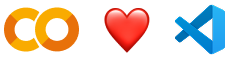

Try the new [Google Colab extension](https://marketplace.visualstudio.com/items?itemName=Google.colab) for Visual Studio Code. You can get up and running in just a few clicks:

*  In VS Code, open the ***Extensions*** view and search for 'Google Colab' to install.
*  Open the kernel selector by creating or opening any `.ipynb` notebook file in your local workspace and either running a cell or clicking the ***Select Kernel*** button in the top right.
*  Click ***Colab*** and then select your desired runtime, sign in with your Google account, and you're all set!

See more details in our [announcement blog here](https://developers.googleblog.com/google-colab-is-coming-to-vs-code).

## 🎁 Free Pro Plan for Gemini & Colab for US College Students 🎓

Get more access to our most accurate model Gemini 3 Pro for advanced coding, complex research, and innovative projects, backed by Colab’s dedicated high-compute resources for data science and machine learning.

Get the Gemini free offer at [gemini.google/students](https://gemini.google/students?utm_source=colab&utm_medium=banner&utm_campaign=students_xpa_us-colab-banner).  
Get the Colab free offer at [colab.research.google.com/signup](https://colab.research.google.com/signup).  
Terms Apply.

## Access popular AI models via Google-Colab-AI Without an API Key
All users have access to most popular LLMs via the `google-colab-ai` Python library, and paid users have access to a wider selection of models. For more details, refer to the [getting started with google colab ai](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/Getting_started_with_google_colab_ai.ipynb).



In [ ]:
from google.colab import ai
response = ai.generate_text("What is the capital of France?")

## Explore the Gemini API
The Gemini API gives you access to Gemini models created by Google DeepMind. Gemini models are built from the ground up to be multimodal, so you can reason seamlessly across text, images, code, and audio.

**How to get started?**
*  Go to [Google AI Studio](https://aistudio.google.com/) and log in with your Google account.
*  [Create an API key](https://aistudio.google.com/app/apikey).
* Use a quickstart for [Python](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started.ipynb), or call the REST API using [curl](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/rest/Prompting_REST.ipynb).

**Discover Gemini's advanced capabilities**
*  Play with Gemini [multimodal outputs](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Image-out.ipynb), mixing text and images in an iterative way.
*  Discover the [multimodal Live API](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_LiveAPI.ipynb ) (demo [here](https://aistudio.google.com/live)).
*  Learn how to [analyze images and detect items in your pictures](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Spatial_understanding.ipynb") using Gemini (bonus, there's a [3D version](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Spatial_understanding_3d.ipynb) as well!).
*  Unlock the power of [Gemini thinking model](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_thinking.ipynb), capable of solving complex task with its inner thoughts.
      
**Explore complex use cases**
*  Use [Gemini grounding capabilities](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Search_grounding_for_research_report.ipynb) to create a report on a company based on what the model can find on internet.
*  Extract [invoices and form data from PDF](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Pdf_structured_outputs_on_invoices_and_forms.ipynb) in a structured way.
*  Create [illustrations based on a whole book](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Book_illustration.ipynb) using Gemini large context window and Imagen.

To learn more, check out the [Gemini cookbook](https://github.com/google-gemini/cookbook) or visit the [Gemini API documentation](https://ai.google.dev/docs/).


Colab now has AI features powered by [Gemini](https://gemini.google.com). The video below provides information on how to use these features, whether you're new to Python, or a seasoned veteran.

<center>
  <a href="https://www.youtube.com/watch?v=V7RXyqFUR98" target="_blank">
  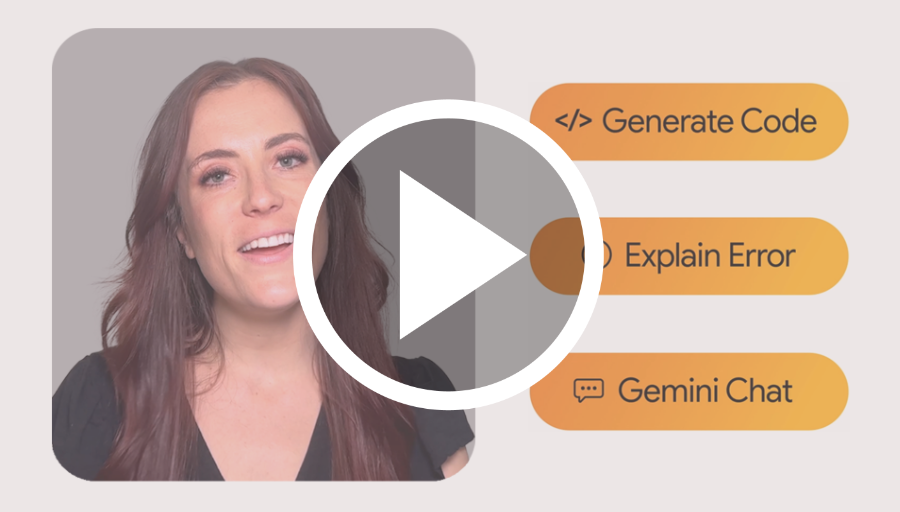
  </a>
</center>

<div class="markdown-google-sans">
  <h2>What is Colab?</h2>
</div>

Colab, or "Colaboratory", allows you to write and execute Python in your browser, with
- Zero configuration required
- Access to GPUs free of charge
- Easy sharing

Whether you're a **student**, a **data scientist** or an **AI researcher**, Colab can make your work easier. Watch [Introduction to Colab](https://www.youtube.com/watch?v=inN8seMm7UI) or [Colab Features You May Have Missed](https://www.youtube.com/watch?v=rNgswRZ2C1Y) to learn more, or just get started below!

<div class="markdown-google-sans">

## **Getting started**
</div>

The document you are reading is not a static web page, but an interactive environment called a **Colab notebook** that lets you write and execute code.

For example, here is a **code cell** with a short Python script that computes a value, stores it in a variable, and prints the result:

In [ ]:
seconds_in_a_day = 24 * 60 * 60
seconds_in_a_day

86400

To execute the code in the above cell, select it with a click and then either press the play button to the left of the code, or use the keyboard shortcut "Command/Ctrl+Enter". To edit the code, just click the cell and start editing.

Variables that you define in one cell can later be used in other cells:

In [ ]:
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

604800

Colab notebooks allow you to combine **executable code** and **rich text** in a single document, along with **images**, **HTML**, **LaTeX** and more. When you create your own Colab notebooks, they are stored in your Google Drive account. You can easily share your Colab notebooks with co-workers or friends, allowing them to comment on your notebooks or even edit them. To learn more, see [Overview of Colab](/notebooks/basic_features_overview.ipynb). To create a new Colab notebook you can use the File menu above, or use the following link: [create a new Colab notebook](http://colab.research.google.com#create=true).

Colab notebooks are Jupyter notebooks that are hosted by Colab. To learn more about the Jupyter project, see [jupyter.org](https://www.jupyter.org).

<div class="markdown-google-sans">

## Data science
</div>

With Colab you can harness the full power of popular Python libraries to analyze and visualize data. The code cell below uses **numpy** to generate some random data, and uses **matplotlib** to visualize it. To edit the code, just click the cell and start editing.

You can import your own data into Colab notebooks from your Google Drive account, including from spreadsheets, as well as from Github and many other sources. To learn more about importing data, and how Colab can be used for data science, see the links below under [Working with Data](#working-with-data).

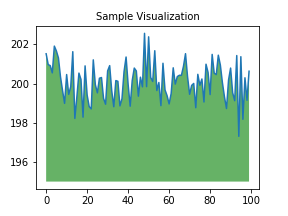

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

Colab notebooks execute code on Google's cloud servers, meaning you can leverage the power of Google hardware, including [GPUs and TPUs](#using-accelerated-hardware), regardless of the power of your machine. All you need is a browser.

For example, if you find yourself waiting for **pandas** code to finish running and want to go faster, you can switch to a GPU Runtime and use libraries like [RAPIDS cuDF](https://rapids.ai/cudf-pandas) that provide zero-code-change acceleration.

To learn more about accelerating pandas on Colab, see the [10 minute guide](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_colab_demo.ipynb) or
 [US stock market data analysis demo](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_stocks_demo.ipynb).

<div class="markdown-google-sans">

## Machine learning
</div>

With Colab you can import an image dataset, train an image classifier on it, and evaluate the model, all in just [a few lines of code](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb).

Colab is used extensively in the machine learning community with applications including:
- Getting started with TensorFlow
- Developing and training neural networks
- Experimenting with TPUs
- Disseminating AI research
- Creating tutorials

To see sample Colab notebooks that demonstrate machine learning applications, see the [machine learning examples](#machine-learning-examples) below.

<div class="markdown-google-sans">

## More Resources

### Working with Notebooks in Colab

</div>

- [Overview of Colab](/notebooks/basic_features_overview.ipynb)
- [Guide to Markdown](/notebooks/markdown_guide.ipynb)
- [Importing libraries and installing dependencies](/notebooks/snippets/importing_libraries.ipynb)
- [Saving and loading notebooks in GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Interactive forms](/notebooks/forms.ipynb)
- [Interactive widgets](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Working with Data
</div>

- [Loading data: Drive, Sheets, and Google Cloud Storage](/notebooks/io.ipynb)
- [Charts: visualizing data](/notebooks/charts.ipynb)
- [Getting started with BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Machine Learning

<div>

These are a few of the notebooks related to Machine Learning, including Google's online Machine Learning course. See the [full course website](https://developers.google.com/machine-learning/crash-course/) for more.
- [Intro to Pandas DataFrame](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Intro to RAPIDS cuDF to accelerate pandas](https://nvda.ws/rapids-cudf)
- [Getting Started with cuML's accelerator mode](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Using Accelerated Hardware
</div>

- [Train a CNN to classify handwritten digits on the MNIST dataset using Flax NNX API](https://colab.research.google.com/github/google/flax/blob/main/docs_nnx/mnist_tutorial.ipynb)
- [Train a Vision Transformer (ViT) for image classification with JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_Vision_transformer.ipynb)
- [Text classification with a transformer language model using JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_transformer_text_classification.ipynb)

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Featured examples

</div>

- [Train a miniGPT language model with JAX AI Stack](https://docs.jaxstack.ai/en/latest/JAX_for_LLM_pretraining.html)
- [LoRA/QLoRA finetuning for LLM using Tunix](https://github.com/google/tunix/blob/main/examples/qlora_gemma.ipynb)
- [Parameter-efficient fine-tuning of Gemma with LoRA and QLoRA](https://keras.io/examples/keras_recipes/parameter_efficient_finetuning_of_gemma_with_lora_and_qlora/)
- [Loading Hugging Face Transformers Checkpoints](https://keras.io/keras_hub/guides/hugging_face_keras_integration/)
- [8-bit Integer Quantization in Keras](https://keras.io/guides/int8_quantization_in_keras/)
- [Float8 training and inference with a simple Transformer model](https://keras.io/examples/keras_recipes/float8_training_and_inference_with_transformer/)
- [Pretraining a Transformer from scratch with KerasHub](https://keras.io/keras_hub/guides/transformer_pretraining/)
- [Simple MNIST convnet](https://keras.io/examples/vision/mnist_convnet/)
- [Image classification from scratch using Keras 3](https://keras.io/examples/vision/image_classification_from_scratch/)
- [Image Classification with KerasHub](https://keras.io/keras_hub/guides/classification_with_keras_hub/)
